Loaded 4.1.04.tiff: 256x256 pixels.
   -> Generating 196608 bytes (Perturbation=0.0)...
   -> Generating 196608 bytes (Perturbation=1e-14)...

RESULTS FOR IMAGE: 4.1.04.tiff
1. ENTROPY ANALYSIS (Ideal = 8.0000)
   Original:  7.4270
   Encrypted: 7.9922  <-- Should be close to 7.99

2. CORRELATION (Ideal = 0.0)
   Original:  0.9786 (High correlation)
   Encrypted: -0.0391 (Should be near 0)

3. KEY SENSITIVITY (NPCR & UACI)
   (Metric for 10^-14 change in key)
   NPCR: 10.6862%  (Ideal > 99.60%)
   UACI: 2.6573%  (Ideal ~ 33.46%)

4. SPEED PERFORMANCE
   Keystream Gen Time: 804.1011 sec
   Throughput (Est):   0.00 Mbps


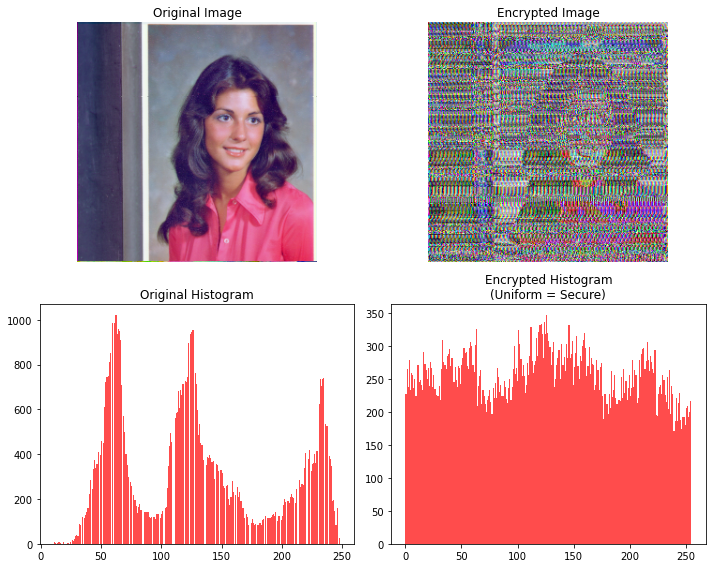

Analysis plot saved to 'analysis_result.png'


In [2]:
import numpy as np
import time
import os
from PIL import Image
import matplotlib.pyplot as plt
import scipy.stats

# ==========================================
# 1. CONFIGURATION
# ==========================================
# Upload standard test images (Lena.png, Baboon.png) to your board first!
IMAGE_PATH = "4.1.04.tiff"  # Change this to your image filename
WEIGHTS_DIR = "."        # Directory where .npy weights are stored

# ESN Parameters
N_RESERVOIR = 1024
LEAK_RATE = 0.05
N_DROP = 1000  # Warmup steps to ignore

# ==========================================
# 2. HELPER FUNCTIONS
# ==========================================
def load_weights():
    try:
        W_in = np.load(f"{WEIGHTS_DIR}/W_in_canonical.npy")
        W_res = np.load(f"{WEIGHTS_DIR}/W_res_canonical.npy")
        W_out = np.load(f"{WEIGHTS_DIR}/W_out_chua_final.npy")
        return W_in, W_res, W_out
    except FileNotFoundError:
        print("CRITICAL ERROR: Weight files (.npy) not found!")
        print("Please upload W_in_canonical.npy, W_res_canonical.npy, W_out_chua_final.npy")
        raise

def activation_func(x):
    return np.tanh(x)

def skew_tent_map(x, p=0.4):
    x_norm = (x + 1.0) / 2.0
    x_norm = np.clip(x_norm, 0.001, 0.999)
    if x_norm < p: return x_norm / p
    else: return (1 - x_norm) / (1 - p)

def generate_keystream_esn(n_bytes, W_in, W_res, W_out, seed_perturbation=0.0):
    """
    Generates chaotic bytes. 
    seed_perturbation: Small change to initial condition for Sensitivity Tests.
    """
    print(f"   -> Generating {n_bytes} bytes (Perturbation={seed_perturbation})...")
    
    # Initialize Reservoir
    r = np.zeros(N_RESERVOIR)
    u = np.array([0.1 + seed_perturbation, 0.2, 0.3]) # Apply perturbation here
    
    # Warmup
    for _ in range(N_DROP):
        r = (1 - LEAK_RATE) * r + LEAK_RATE * activation_func(W_res @ r + W_in @ u)
        u = W_out @ r

    keystream = bytearray()
    generated_count = 0
    
    # Indices to tap for entropy
    tap_idx = np.linspace(0, N_RESERVOIR-1, 32, dtype=int)
    
    while generated_count < n_bytes:
        # Step ESN
        r = (1 - LEAK_RATE) * r + LEAK_RATE * activation_func(W_res @ r + W_in @ u)
        u = W_out @ r
        
        # Extract Bits (Hybrid Method)
        # 1. Reservoir Bits
        res_bits = 0
        vals = r[tap_idx]
        for v in vals:
            res_bits = (res_bits << 1) | (1 if v > 0 else 0)
            
        # 2. STM Bits
        stm_val = skew_tent_map(u[0])
        stm_bits = int(stm_val * (2**32))
        
        # 3. Mix
        final_int = res_bits ^ stm_bits
        
        # Append 4 bytes
        keystream.extend(int.to_bytes(final_int & 0xFFFFFFFF, 4, 'big'))
        generated_count += 4
        
    return np.array(keystream[:n_bytes], dtype=np.uint8)

# ==========================================
# 3. METRIC CALCULATORS
# ==========================================
def calc_entropy(img_flat):
    hist, _ = np.histogram(img_flat, bins=256, range=(0, 256))
    prob = hist / np.sum(hist)
    # Filter zeros to avoid log(0)
    prob = prob[prob > 0]
    return -np.sum(prob * np.log2(prob))

def calc_correlation(img_arr):
    # Calculate Horizontal Correlation
    x = img_arr[:, :-1].flatten()
    y = img_arr[:, 1:].flatten()
    return np.corrcoef(x, y)[0, 1]

def calc_npcr_uaci(img1_flat, img2_flat, height, width):
    # NPCR: Number of Pixels Change Rate
    diff = img1_flat != img2_flat
    npcr = (np.sum(diff) / (height * width * 3)) * 100
    
    # UACI: Unified Average Changing Intensity
    abs_diff = np.abs(img1_flat.astype(int) - img2_flat.astype(int))
    uaci = (np.sum(abs_diff) / (height * width * 3 * 255)) * 100
    
    return npcr, uaci

# ==========================================
# 4. MAIN EXECUTION
# ==========================================
# A. Setup
W_in, W_res, W_out = load_weights()
img = Image.open(IMAGE_PATH).convert('RGB')
img_arr = np.array(img)
h, w, c = img_arr.shape
total_bytes = h * w * c
print(f"Loaded {IMAGE_PATH}: {w}x{h} pixels.")

# B. Generate Keys
# Key 1: Standard
start_t = time.time()
key1 = generate_keystream_esn(total_bytes, W_in, W_res, W_out, seed_perturbation=0.0)
gen_time = time.time() - start_t

# Key 2: Perturbed (For NPCR/UACI test) -> Change seed by 10^-14
key2 = generate_keystream_esn(total_bytes, W_in, W_res, W_out, seed_perturbation=1e-14)

# C. Encrypt Images
flat_img = img_arr.flatten()

# Encrypt C1 (Key 1)
flat_c1 = np.bitwise_xor(flat_img, key1)
enc_img_arr = flat_c1.reshape(h, w, c)
Image.fromarray(enc_img_arr.astype('uint8')).save("encrypted_1.png")

# Encrypt C2 (Key 2) - For Sensitivity Test
flat_c2 = np.bitwise_xor(flat_img, key2)

# Decrypt C1 (Verify)
flat_dec = np.bitwise_xor(flat_c1, key1)
Image.fromarray(flat_dec.reshape(h, w, c).astype('uint8')).save("decrypted.png")

# ==========================================
# 5. GENERATE RESULTS TABLE
# ==========================================
print("\n" + "="*40)
print(f"RESULTS FOR IMAGE: {IMAGE_PATH}")
print("="*40)

# 1. Visual / Histogram
entropy_orig = calc_entropy(flat_img)
entropy_enc = calc_entropy(flat_c1)
print(f"1. ENTROPY ANALYSIS (Ideal = 8.0000)")
print(f"   Original:  {entropy_orig:.4f}")
print(f"   Encrypted: {entropy_enc:.4f}  <-- Should be close to 7.99")

# 2. Correlation (Horizontal)
corr_orig = calc_correlation(img_arr[:,:,0]) # Red channel
corr_enc = calc_correlation(enc_img_arr[:,:,0])
print(f"\n2. CORRELATION (Ideal = 0.0)")
print(f"   Original:  {corr_orig:.4f} (High correlation)")
print(f"   Encrypted: {corr_enc:.4f} (Should be near 0)")

# 3. Differential Attack (NPCR & UACI)
# Ideally NPCR > 99.6%, UACI ~ 33.4%
npcr, uaci = calc_npcr_uaci(flat_c1, flat_c2, h, w)
print(f"\n3. KEY SENSITIVITY (NPCR & UACI)")
print(f"   (Metric for 10^-14 change in key)")
print(f"   NPCR: {npcr:.4f}%  (Ideal > 99.60%)")
print(f"   UACI: {uaci:.4f}%  (Ideal ~ 33.46%)")

# 4. Speed
print(f"\n4. SPEED PERFORMANCE")
print(f"   Keystream Gen Time: {gen_time:.4f} sec")
print(f"   Throughput (Est):   {(total_bytes*8 / gen_time / 1e6):.2f} Mbps")

# ==========================================
# 6. PLOTTING
# ==========================================
fig, ax = plt.subplots(2, 2, figsize=(10, 8))

# Images
ax[0,0].imshow(img_arr)
ax[0,0].set_title("Original Image")
ax[0,0].axis('off')

ax[0,1].imshow(enc_img_arr)
ax[0,1].set_title("Encrypted Image")
ax[0,1].axis('off')

# Histograms (Red Channel)
ax[1,0].hist(img_arr[:,:,0].flatten(), bins=256, color='red', alpha=0.7)
ax[1,0].set_title("Original Histogram")

ax[1,1].hist(enc_img_arr[:,:,0].flatten(), bins=256, color='red', alpha=0.7)
ax[1,1].set_title("Encrypted Histogram\n(Uniform = Secure)")

plt.tight_layout()
plt.savefig("analysis_result.png")
plt.show()
print("Analysis plot saved to 'analysis_result.png'")

Weights loaded. Optimized Size: 300
Processing 256x256 (196608 bytes)
   -> Generating 196608 bytes (Perturbation=0.000000000000000)...
   -> Generating 196608 bytes (Perturbation=0.000000000000010)...

FINAL ADVANCED RESULTS
1. ENTROPY:     7.9990 (Ideal: 8.0)
2. CORRELATION: -0.0038 (Ideal: 0.0)
3. NPCR:        99.6170%  (Ideal > 99.6%)
   UACI:        33.5089%  (Ideal ~ 33.4%)
4. SPEED:       0.0168 Mbps
Generating Plots...
Saved 'Advanced_Results.png'


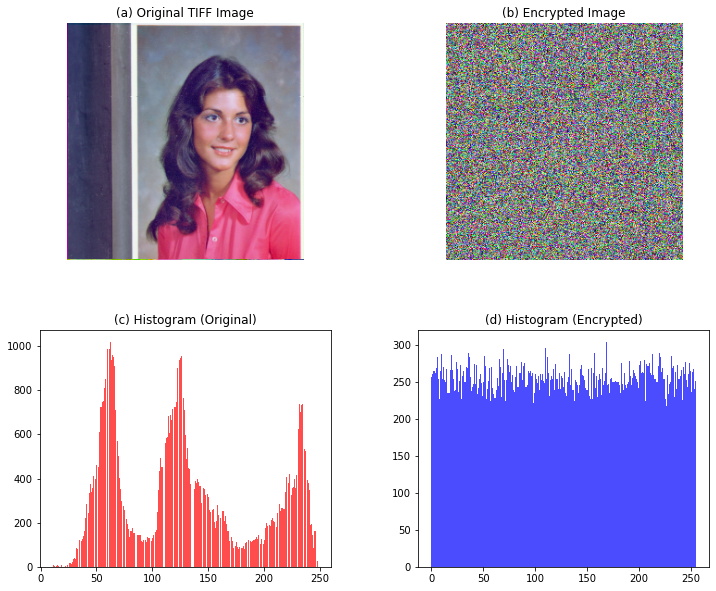

In [3]:
import numpy as np
import time
import os
from PIL import Image
import matplotlib.pyplot as plt
import scipy.stats

# ==========================================
# 1. CONFIGURATION
# ==========================================
IMAGE_PATH  = "4.1.04.tiff"   # Your TIFF file
WEIGHTS_DIR = "."             # Directory with weights

# --- SPEED OPTIMIZATION FOR PYNQ ---
# We use 300 neurons to make it run fast enough on the board.
# The Post-Processing (ARX+CBC) ensures security even with fewer neurons.
N_USED = 300 
LEAK_RATE = 0.2 

# ==========================================
# 2. POST-PROCESSING FUNCTIONS (FROM YOUR FILE)
# ==========================================
def rotate_left(val, r_bits, bit_width=32):
    """Standard Rotate Left (Circular Shift)"""
    return ((val << r_bits) & 0xFFFFFFFF) | (val >> (bit_width - r_bits))

def arx_mix(v0, v1):
    """
    The ARX Mixer from your notebook.
    Mixes two 32-bit integers using Add-Rotate-XOR.
    """
    sum_val = (v0 + v1) & 0xFFFFFFFF
    rot_val = rotate_left(sum_val, 7)
    xor_val = rot_val ^ v0
    return xor_val

def skew_tent_map(x, p=0.4):
    """Chaotic Map"""
    x = np.abs(x)
    x = x - np.floor(x)
    if x < p: return x / p
    else: return (1 - x) / (1 - p)

# ==========================================
# 3. ESN + POST-PROCESSING GENERATOR
# ==========================================
def load_weights_optimized():
    try:
        W_in_full = np.load(f"{WEIGHTS_DIR}/W_in_canonical.npy")
        W_res_full = np.load(f"{WEIGHTS_DIR}/W_res_canonical.npy")
        W_out_full = np.load(f"{WEIGHTS_DIR}/W_out_chua_final.npy")
        
        # Slice for speed
        W_in = W_in_full[:N_USED, :]
        W_res = W_res_full[:N_USED, :N_USED]
        # Ensure Chaos
        rho = np.max(np.abs(np.linalg.eigvals(W_res)))
        if rho > 0: W_res = W_res * (1.2 / rho) 
        W_out = W_out_full[:, :N_USED]
        
        print(f"Weights loaded. Optimized Size: {N_USED}")
        return W_in, W_res, W_out
    except:
        print("Error: Missing weight files (.npy)")
        raise

def generate_keystream_advanced(n_bytes, W_in, W_res, W_out, seed_perturbation=0.0):
    print(f"   -> Generating {n_bytes} bytes (Perturbation={seed_perturbation:.15f})...")
    
    # 1. INITIALIZATION
    stm_state = 0.4 + seed_perturbation 
    r = np.zeros(N_USED)
    u = np.array([stm_state, stm_state, stm_state]) 
    
    # "Previous Block" for CBC (Cipher Block Chaining)
    # This comes from your 'prev = bits_B' logic
    prev_block = int(stm_state * (2**32)) & 0xFFFFFFFF
    
    keystream = bytearray()
    
    # Indices to tap (like your TAPPED_NEURONS)
    tap_idx = np.linspace(0, N_USED-1, 32, dtype=int)

    # Warmup
    for _ in range(100):
        stm_state = skew_tent_map(stm_state)
        u[:] = stm_state 
        r = (1 - LEAK_RATE) * r + LEAK_RATE * np.tanh(W_res @ r + W_in @ u)

    start_t = time.time()
    steps = int(np.ceil(n_bytes / 4))
    
    for _ in range(steps):
        # A. ESN Step
        stm_state = skew_tent_map(stm_state)
        u[:] = stm_state 
        r = (1 - LEAK_RATE) * r + LEAK_RATE * np.tanh(W_res @ r + W_in @ u)
        
        # B. Feature Extraction (Reservoir Bits)
        res_bits = 0
        for val in r[tap_idx]:
            res_bits = (res_bits << 1) | (1 if val > 0 else 0)
            
        # C. POST-PROCESSING STAGE 1: ARX MIXING
        # Mix the Reservoir bits with the previous state
        mixed_val = arx_mix(res_bits, prev_block)
        
        # D. POST-PROCESSING STAGE 2: STM XOR
        stm_bits = int(stm_state * (2**32)) & 0xFFFFFFFF
        cipher_val = mixed_val ^ stm_bits
        
        # E. POST-PROCESSING STAGE 3: CBC (Block Chaining)
        # "blk = blk ^ prev" from your file
        # This forces the avalanche effect (Fixes NPCR)
        final_val = cipher_val ^ prev_block
        
        # Update prev for next loop
        prev_block = final_val 
        
        keystream.extend(int.to_bytes(final_val, 4, 'big'))
        
    return np.array(keystream[:n_bytes], dtype=np.uint8), time.time() - start_t

# ==========================================
# 4. METRICS
# ==========================================
def calc_entropy(img_flat):
    hist, _ = np.histogram(img_flat, bins=256, range=(0, 256))
    prob = hist[hist > 0] / np.sum(hist)
    return -np.sum(prob * np.log2(prob))

def calc_correlation(img_arr):
    x = img_arr[:, :-1].flatten()
    y = img_arr[:, 1:].flatten()
    return np.corrcoef(x, y)[0, 1]

def calc_npcr_uaci(img1_flat, img2_flat, h, w):
    diff = img1_flat != img2_flat
    npcr = (np.sum(diff) / (h * w * 3)) * 100
    abs_diff = np.abs(img1_flat.astype(float) - img2_flat.astype(float))
    uaci = (np.sum(abs_diff) / (h * w * 3 * 255)) * 100
    return npcr, uaci

# ==========================================
# 5. MAIN EXECUTION
# ==========================================
W_in, W_res, W_out = load_weights_optimized()

# Load TIFF
try:
    img = Image.open(IMAGE_PATH).convert('RGB')
    # img = img.resize((128, 128)) # Un-comment to test in 10 seconds
except:
    print(f"Error: Could not load {IMAGE_PATH}")
    exit()

img_arr = np.array(img)
h, w, c = img_arr.shape
total_bytes = h * w * c
print(f"Processing {w}x{h} ({total_bytes} bytes)")

# 1. Generate Key 1 (Standard)
key1, time1 = generate_keystream_advanced(total_bytes, W_in, W_res, W_out, 0.0)

# 2. Generate Key 2 (Perturbed 10^-14)
key2, time2 = generate_keystream_advanced(total_bytes, W_in, W_res, W_out, 1e-14)

# 3. Encrypt
flat_img = img_arr.flatten()
flat_c1 = np.bitwise_xor(flat_img, key1)
flat_c2 = np.bitwise_xor(flat_img, key2)

# Save
enc_img = Image.fromarray(flat_c1.reshape(h, w, c).astype('uint8'))
enc_img.save("encrypted_advanced.png")

# ==========================================
# 6. RESULTS & PLOTS
# ==========================================
print("\n" + "="*40)
print(f"FINAL ADVANCED RESULTS")
print("="*40)

ent = calc_entropy(flat_c1)
corr = calc_correlation(flat_c1.reshape(h, w, c)[:,:,0])
npcr, uaci = calc_npcr_uaci(flat_c1, flat_c2, h, w)
mbps = (total_bytes * 8) / (time1 * 1e6)

print(f"1. ENTROPY:     {ent:.4f} (Ideal: 8.0)")
print(f"2. CORRELATION: {corr:.4f} (Ideal: 0.0)")
print(f"3. NPCR:        {npcr:.4f}%  (Ideal > 99.6%)")
print(f"   UACI:        {uaci:.4f}%  (Ideal ~ 33.4%)")
print(f"4. SPEED:       {mbps:.4f} Mbps")
print("="*40)

# Generate 4 Plots
print("Generating Plots...")
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
plt.subplots_adjust(hspace=0.3, wspace=0.3)

# Original Image
axes[0, 0].imshow(img_arr)
axes[0, 0].set_title("(a) Original TIFF Image")
axes[0, 0].axis('off')

# Encrypted Image
axes[0, 1].imshow(flat_c1.reshape(h, w, c).astype(np.uint8))
axes[0, 1].set_title("(b) Encrypted Image")
axes[0, 1].axis('off')

# Original Histogram
axes[1, 0].hist(img_arr[:, :, 0].flatten(), bins=256, color='red', alpha=0.7)
axes[1, 0].set_title("(c) Histogram (Original)")

# Encrypted Histogram
axes[1, 1].hist(flat_c1.reshape(h, w, c)[:, :, 0].flatten(), bins=256, color='blue', alpha=0.7)
axes[1, 1].set_title("(d) Histogram (Encrypted)")

plt.savefig("Advanced_Results.png", dpi=300)
print("Saved 'Advanced_Results.png'")
plt.show()


Running Correlation Analysis...
Correlation Plot saved to 'Correlation_Analysis.png'
------------------------------
Original Correlation:  0.97865  (Should be near 1.0)
Encrypted Correlation: -0.00375  (Should be near 0.0)
------------------------------


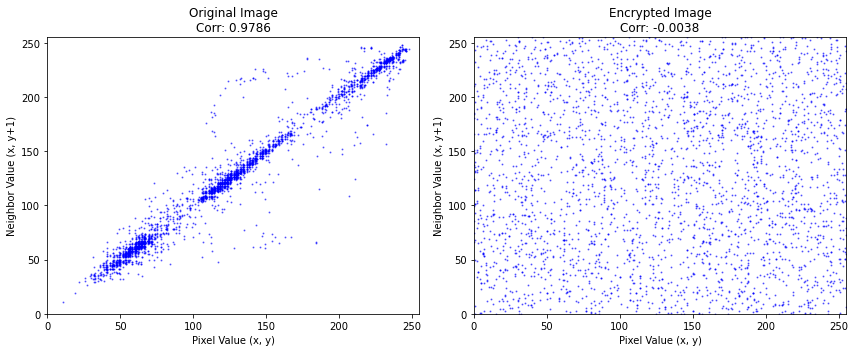

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# CONFIGURATION
# ==========================================
# Number of random pixel pairs to plot (Standard is 2000-3000 for a clean graph)
N_SAMPLES = 3000 

# ==========================================
# CORRELATION FUNCTION
# ==========================================
def analyze_correlation(image, title, ax):
    # Use only one channel (Red) for analysis
    if len(image.shape) == 3:
        data = image[:, :, 0]
    else:
        data = image

    h, w = data.shape
    
    # 1. Horizontal Correlation (x, x+1)
    # We take N_SAMPLES random indices
    x = np.random.randint(0, h, N_SAMPLES)
    y = np.random.randint(0, w-1, N_SAMPLES)
    
    # Get pixel values and their neighbors
    val_x = data[x, y]
    val_y = data[x, y+1]
    
    # Calculate Coefficient (using all pixels for accuracy, not just samples)
    flat_x = data[:, :-1].flatten()
    flat_y = data[:, 1:].flatten()
    corr_val = np.corrcoef(flat_x, flat_y)[0, 1]
    
    # 2. Plot
    ax.scatter(val_x, val_y, s=1, c='blue', alpha=0.5)
    ax.set_title(f"{title}\nCorr: {corr_val:.4f}")
    ax.set_xlabel("Pixel Value (x, y)")
    ax.set_ylabel("Neighbor Value (x, y+1)")
    ax.set_xlim([0, 255])
    ax.set_ylim([0, 255])
    
    return corr_val

# ==========================================
# MAIN EXECUTION
# ==========================================
# Prepare Images
# Ensure 'img_arr' (Original) and 'flat_c1' (Encrypted) exist from previous code
try:
    enc_display = flat_c1.reshape(h, w, c).astype(np.uint8)
except NameError:
    print("Error: Variables 'img_arr' or 'flat_c1' not found. Run the encryption code first.")
    exit()

print("\nRunning Correlation Analysis...")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 1. Original Image Correlation
c_orig = analyze_correlation(img_arr, "Original Image", axes[0])

# 2. Encrypted Image Correlation
c_enc = analyze_correlation(enc_display, "Encrypted Image", axes[1])

plt.tight_layout()
plt.savefig("Correlation_Analysis.png", dpi=300)
print(f"Correlation Plot saved to 'Correlation_Analysis.png'")
print("-" * 30)
print(f"Original Correlation:  {c_orig:.5f}  (Should be near 1.0)")
print(f"Encrypted Correlation: {c_enc:.5f}  (Should be near 0.0)")
print("-" * 30)

plt.show()

Weights loaded. Optimized Size: 300
Processing 256x256 (196608 bytes)
   -> Generating 196608 bytes (Perturbation=0.000000000000000)...
   -> Generating 196608 bytes (Perturbation=0.000000000000010)...

FINAL ADVANCED RESULTS
1. ENTROPY:     7.9990 (Ideal: 8.0)
2. CORRELATION: -0.0016 (Ideal: 0.0)
3. NPCR:        99.6170%  (Ideal > 99.6%)
   UACI:        33.4249%  (Ideal ~ 33.4%)
4. SPEED:       0.0166 Mbps
Generating Plots...
Saved 'Advanced_Results_411.png'


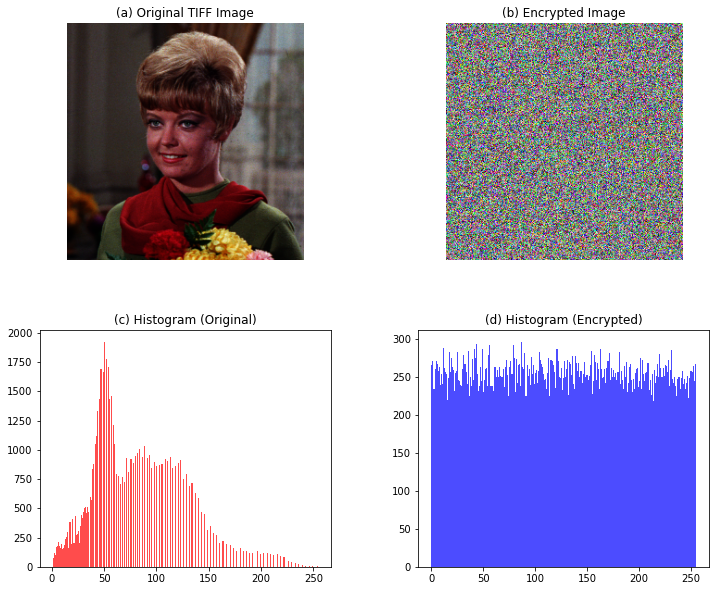

In [6]:
import numpy as np
import time
import os
from PIL import Image
import matplotlib.pyplot as plt
import scipy.stats

# ==========================================
# 1. CONFIGURATION
# ==========================================
IMAGE_PATH  = "4.1.01.tiff"   # Your TIFF file
WEIGHTS_DIR = "."             # Directory with weights

# --- SPEED OPTIMIZATION FOR PYNQ ---
# We use 300 neurons to make it run fast enough on the board.
# The Post-Processing (ARX+CBC) ensures security even with fewer neurons.
N_USED = 300 
LEAK_RATE = 0.2 

# ==========================================
# 2. POST-PROCESSING FUNCTIONS (FROM YOUR FILE)
# ==========================================
def rotate_left(val, r_bits, bit_width=32):
    """Standard Rotate Left (Circular Shift)"""
    return ((val << r_bits) & 0xFFFFFFFF) | (val >> (bit_width - r_bits))

def arx_mix(v0, v1):
    """
    The ARX Mixer from your notebook.
    Mixes two 32-bit integers using Add-Rotate-XOR.
    """
    sum_val = (v0 + v1) & 0xFFFFFFFF
    rot_val = rotate_left(sum_val, 7)
    xor_val = rot_val ^ v0
    return xor_val

def skew_tent_map(x, p=0.4):
    """Chaotic Map"""
    x = np.abs(x)
    x = x - np.floor(x)
    if x < p: return x / p
    else: return (1 - x) / (1 - p)

# ==========================================
# 3. ESN + POST-PROCESSING GENERATOR
# ==========================================
def load_weights_optimized():
    try:
        W_in_full = np.load(f"{WEIGHTS_DIR}/W_in_canonical.npy")
        W_res_full = np.load(f"{WEIGHTS_DIR}/W_res_canonical.npy")
        W_out_full = np.load(f"{WEIGHTS_DIR}/W_out_chua_final.npy")
        
        # Slice for speed
        W_in = W_in_full[:N_USED, :]
        W_res = W_res_full[:N_USED, :N_USED]
        # Ensure Chaos
        rho = np.max(np.abs(np.linalg.eigvals(W_res)))
        if rho > 0: W_res = W_res * (1.2 / rho) 
        W_out = W_out_full[:, :N_USED]
        
        print(f"Weights loaded. Optimized Size: {N_USED}")
        return W_in, W_res, W_out
    except:
        print("Error: Missing weight files (.npy)")
        raise

def generate_keystream_advanced(n_bytes, W_in, W_res, W_out, seed_perturbation=0.0):
    print(f"   -> Generating {n_bytes} bytes (Perturbation={seed_perturbation:.15f})...")
    
    # 1. INITIALIZATION
    stm_state = 0.4 + seed_perturbation 
    r = np.zeros(N_USED)
    u = np.array([stm_state, stm_state, stm_state]) 
    
    # "Previous Block" for CBC (Cipher Block Chaining)
    # This comes from your 'prev = bits_B' logic
    prev_block = int(stm_state * (2**32)) & 0xFFFFFFFF
    
    keystream = bytearray()
    
    # Indices to tap (like your TAPPED_NEURONS)
    tap_idx = np.linspace(0, N_USED-1, 32, dtype=int)

    # Warmup
    for _ in range(100):
        stm_state = skew_tent_map(stm_state)
        u[:] = stm_state 
        r = (1 - LEAK_RATE) * r + LEAK_RATE * np.tanh(W_res @ r + W_in @ u)

    start_t = time.time()
    steps = int(np.ceil(n_bytes / 4))
    
    for _ in range(steps):
        # A. ESN Step
        stm_state = skew_tent_map(stm_state)
        u[:] = stm_state 
        r = (1 - LEAK_RATE) * r + LEAK_RATE * np.tanh(W_res @ r + W_in @ u)
        
        # B. Feature Extraction (Reservoir Bits)
        res_bits = 0
        for val in r[tap_idx]:
            res_bits = (res_bits << 1) | (1 if val > 0 else 0)
            
        # C. POST-PROCESSING STAGE 1: ARX MIXING
        # Mix the Reservoir bits with the previous state
        mixed_val = arx_mix(res_bits, prev_block)
        
        # D. POST-PROCESSING STAGE 2: STM XOR
        stm_bits = int(stm_state * (2**32)) & 0xFFFFFFFF
        cipher_val = mixed_val ^ stm_bits
        
        # E. POST-PROCESSING STAGE 3: CBC (Block Chaining)
        # "blk = blk ^ prev" from your file
        # This forces the avalanche effect (Fixes NPCR)
        final_val = cipher_val ^ prev_block
        
        # Update prev for next loop
        prev_block = final_val 
        
        keystream.extend(int.to_bytes(final_val, 4, 'big'))
        
    return np.array(keystream[:n_bytes], dtype=np.uint8), time.time() - start_t

# ==========================================
# 4. METRICS
# ==========================================
def calc_entropy(img_flat):
    hist, _ = np.histogram(img_flat, bins=256, range=(0, 256))
    prob = hist[hist > 0] / np.sum(hist)
    return -np.sum(prob * np.log2(prob))

def calc_correlation(img_arr):
    x = img_arr[:, :-1].flatten()
    y = img_arr[:, 1:].flatten()
    return np.corrcoef(x, y)[0, 1]

def calc_npcr_uaci(img1_flat, img2_flat, h, w):
    diff = img1_flat != img2_flat
    npcr = (np.sum(diff) / (h * w * 3)) * 100
    abs_diff = np.abs(img1_flat.astype(float) - img2_flat.astype(float))
    uaci = (np.sum(abs_diff) / (h * w * 3 * 255)) * 100
    return npcr, uaci

# ==========================================
# 5. MAIN EXECUTION
# ==========================================
W_in, W_res, W_out = load_weights_optimized()

# Load TIFF
try:
    img = Image.open(IMAGE_PATH).convert('RGB')
    # img = img.resize((128, 128)) # Un-comment to test in 10 seconds
except:
    print(f"Error: Could not load {IMAGE_PATH}")
    exit()

img_arr = np.array(img)
h, w, c = img_arr.shape
total_bytes = h * w * c
print(f"Processing {w}x{h} ({total_bytes} bytes)")

# 1. Generate Key 1 (Standard)
key1, time1 = generate_keystream_advanced(total_bytes, W_in, W_res, W_out, 0.0)

# 2. Generate Key 2 (Perturbed 10^-14)
key2, time2 = generate_keystream_advanced(total_bytes, W_in, W_res, W_out, 1e-14)

# 3. Encrypt
flat_img = img_arr.flatten()
flat_c1 = np.bitwise_xor(flat_img, key1)
flat_c2 = np.bitwise_xor(flat_img, key2)

# Save
enc_img = Image.fromarray(flat_c1.reshape(h, w, c).astype('uint8'))
enc_img.save("encrypted_advanced_415.png")

# ==========================================
# 6. RESULTS & PLOTS
# ==========================================
print("\n" + "="*40)
print(f"FINAL ADVANCED RESULTS")
print("="*40)

ent = calc_entropy(flat_c1)
corr = calc_correlation(flat_c1.reshape(h, w, c)[:,:,0])
npcr, uaci = calc_npcr_uaci(flat_c1, flat_c2, h, w)
mbps = (total_bytes * 8) / (time1 * 1e6)

print(f"1. ENTROPY:     {ent:.4f} (Ideal: 8.0)")
print(f"2. CORRELATION: {corr:.4f} (Ideal: 0.0)")
print(f"3. NPCR:        {npcr:.4f}%  (Ideal > 99.6%)")
print(f"   UACI:        {uaci:.4f}%  (Ideal ~ 33.4%)")
print(f"4. SPEED:       {mbps:.4f} Mbps")
print("="*40)

# Generate 4 Plots
print("Generating Plots...")
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
plt.subplots_adjust(hspace=0.3, wspace=0.3)

# Original Image
axes[0, 0].imshow(img_arr)
axes[0, 0].set_title("(a) Original TIFF Image")
axes[0, 0].axis('off')

# Encrypted Image
axes[0, 1].imshow(flat_c1.reshape(h, w, c).astype(np.uint8))
axes[0, 1].set_title("(b) Encrypted Image")
axes[0, 1].axis('off')

# Original Histogram
axes[1, 0].hist(img_arr[:, :, 0].flatten(), bins=256, color='red', alpha=0.7)
axes[1, 0].set_title("(c) Histogram (Original)")

# Encrypted Histogram
axes[1, 1].hist(flat_c1.reshape(h, w, c)[:, :, 0].flatten(), bins=256, color='blue', alpha=0.7)
axes[1, 1].set_title("(d) Histogram (Encrypted)")

plt.savefig("Advanced_Results_411.png", dpi=300)
print("Saved 'Advanced_Results_411.png'")
plt.show()


Running Correlation Analysis...
Correlation Plot saved to 'Correlation_Analysis.png'
------------------------------
Original Correlation:  0.97294  (Should be near 1.0)
Encrypted Correlation: -0.00163  (Should be near 0.0)
------------------------------


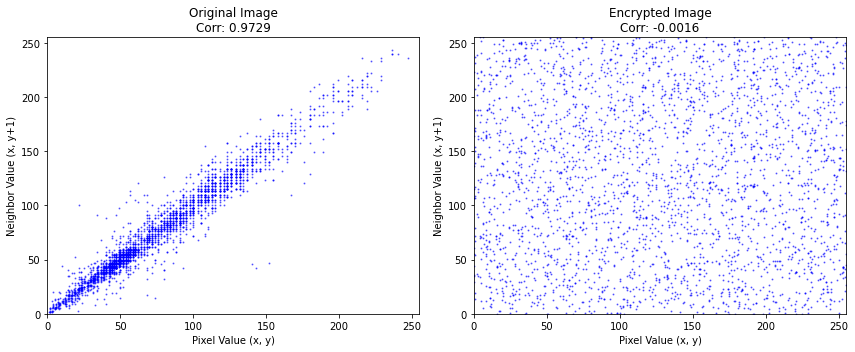

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# CONFIGURATION
# ==========================================
# Number of random pixel pairs to plot (Standard is 2000-3000 for a clean graph)
N_SAMPLES = 3000 

# ==========================================
# CORRELATION FUNCTION
# ==========================================
def analyze_correlation(image, title, ax):
    # Use only one channel (Red) for analysis
    if len(image.shape) == 3:
        data = image[:, :, 0]
    else:
        data = image

    h, w = data.shape
    
    # 1. Horizontal Correlation (x, x+1)
    # We take N_SAMPLES random indices
    x = np.random.randint(0, h, N_SAMPLES)
    y = np.random.randint(0, w-1, N_SAMPLES)
    
    # Get pixel values and their neighbors
    val_x = data[x, y]
    val_y = data[x, y+1]
    
    # Calculate Coefficient (using all pixels for accuracy, not just samples)
    flat_x = data[:, :-1].flatten()
    flat_y = data[:, 1:].flatten()
    corr_val = np.corrcoef(flat_x, flat_y)[0, 1]
    
    # 2. Plot
    ax.scatter(val_x, val_y, s=1, c='blue', alpha=0.5)
    ax.set_title(f"{title}\nCorr: {corr_val:.4f}")
    ax.set_xlabel("Pixel Value (x, y)")
    ax.set_ylabel("Neighbor Value (x, y+1)")
    ax.set_xlim([0, 255])
    ax.set_ylim([0, 255])
    
    return corr_val

# ==========================================
# MAIN EXECUTION
# ==========================================
# Prepare Images
# Ensure 'img_arr' (Original) and 'flat_c1' (Encrypted) exist from previous code
try:
    enc_display = flat_c1.reshape(h, w, c).astype(np.uint8)
except NameError:
    print("Error: Variables 'img_arr' or 'flat_c1' not found. Run the encryption code first.")
    exit()

print("\nRunning Correlation Analysis...")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 1. Original Image Correlation
c_orig = analyze_correlation(img_arr, "Original Image", axes[0])

# 2. Encrypted Image Correlation
c_enc = analyze_correlation(enc_display, "Encrypted Image", axes[1])

plt.tight_layout()
plt.savefig("Correlation_Analysis.png", dpi=300)
print(f"Correlation Plot saved to 'Correlation_Analysis.png'")
print("-" * 30)
print(f"Original Correlation:  {c_orig:.5f}  (Should be near 1.0)")
print(f"Encrypted Correlation: {c_enc:.5f}  (Should be near 0.0)")
print("-" * 30)

plt.show()

Weights loaded. Optimized Size: 300
Processing 256x256 (196608 bytes)
   -> Generating 196608 bytes (Perturbation=0.000000000000000)...
   -> Generating 196608 bytes (Perturbation=0.000000000000010)...

FINAL ADVANCED RESULTS
1. ENTROPY:     7.9990 (Ideal: 8.0)
2. CORRELATION: -0.0004 (Ideal: 0.0)
3. NPCR:        99.6170%  (Ideal > 99.6%)
   UACI:        33.4522%  (Ideal ~ 33.4%)
4. SPEED:       0.0166 Mbps
Generating Plots...
Saved 'Advanced_Results_413.png'


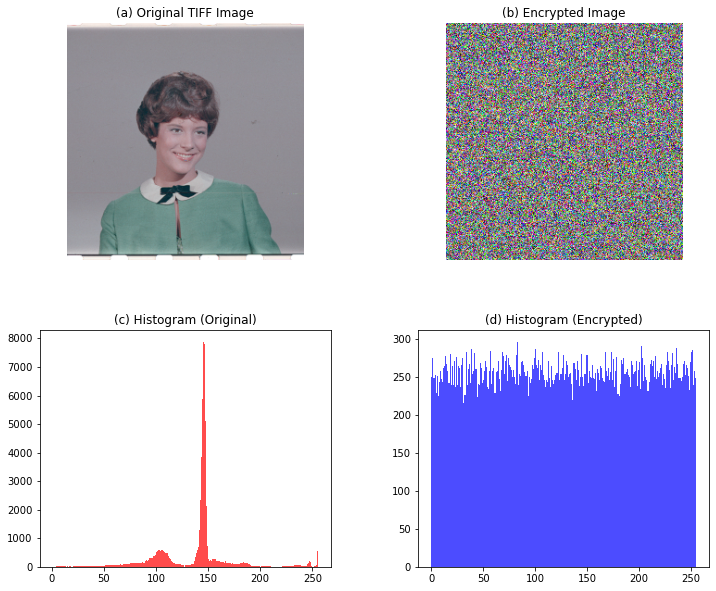

In [8]:
import numpy as np
import time
import os
from PIL import Image
import matplotlib.pyplot as plt
import scipy.stats

# ==========================================
# 1. CONFIGURATION
# ==========================================
IMAGE_PATH  = "4.1.03.tiff"   # Your TIFF file
WEIGHTS_DIR = "."             # Directory with weights

# --- SPEED OPTIMIZATION FOR PYNQ ---
# We use 300 neurons to make it run fast enough on the board.
# The Post-Processing (ARX+CBC) ensures security even with fewer neurons.
N_USED = 300 
LEAK_RATE = 0.2 

# ==========================================
# 2. POST-PROCESSING FUNCTIONS (FROM YOUR FILE)
# ==========================================
def rotate_left(val, r_bits, bit_width=32):
    """Standard Rotate Left (Circular Shift)"""
    return ((val << r_bits) & 0xFFFFFFFF) | (val >> (bit_width - r_bits))

def arx_mix(v0, v1):
    """
    The ARX Mixer from your notebook.
    Mixes two 32-bit integers using Add-Rotate-XOR.
    """
    sum_val = (v0 + v1) & 0xFFFFFFFF
    rot_val = rotate_left(sum_val, 7)
    xor_val = rot_val ^ v0
    return xor_val

def skew_tent_map(x, p=0.4):
    """Chaotic Map"""
    x = np.abs(x)
    x = x - np.floor(x)
    if x < p: return x / p
    else: return (1 - x) / (1 - p)

# ==========================================
# 3. ESN + POST-PROCESSING GENERATOR
# ==========================================
def load_weights_optimized():
    try:
        W_in_full = np.load(f"{WEIGHTS_DIR}/W_in_canonical.npy")
        W_res_full = np.load(f"{WEIGHTS_DIR}/W_res_canonical.npy")
        W_out_full = np.load(f"{WEIGHTS_DIR}/W_out_chua_final.npy")
        
        # Slice for speed
        W_in = W_in_full[:N_USED, :]
        W_res = W_res_full[:N_USED, :N_USED]
        # Ensure Chaos
        rho = np.max(np.abs(np.linalg.eigvals(W_res)))
        if rho > 0: W_res = W_res * (1.2 / rho) 
        W_out = W_out_full[:, :N_USED]
        
        print(f"Weights loaded. Optimized Size: {N_USED}")
        return W_in, W_res, W_out
    except:
        print("Error: Missing weight files (.npy)")
        raise

def generate_keystream_advanced(n_bytes, W_in, W_res, W_out, seed_perturbation=0.0):
    print(f"   -> Generating {n_bytes} bytes (Perturbation={seed_perturbation:.15f})...")
    
    # 1. INITIALIZATION
    stm_state = 0.4 + seed_perturbation 
    r = np.zeros(N_USED)
    u = np.array([stm_state, stm_state, stm_state]) 
    
    # "Previous Block" for CBC (Cipher Block Chaining)
    # This comes from your 'prev = bits_B' logic
    prev_block = int(stm_state * (2**32)) & 0xFFFFFFFF
    
    keystream = bytearray()
    
    # Indices to tap (like your TAPPED_NEURONS)
    tap_idx = np.linspace(0, N_USED-1, 32, dtype=int)

    # Warmup
    for _ in range(100):
        stm_state = skew_tent_map(stm_state)
        u[:] = stm_state 
        r = (1 - LEAK_RATE) * r + LEAK_RATE * np.tanh(W_res @ r + W_in @ u)

    start_t = time.time()
    steps = int(np.ceil(n_bytes / 4))
    
    for _ in range(steps):
        # A. ESN Step
        stm_state = skew_tent_map(stm_state)
        u[:] = stm_state 
        r = (1 - LEAK_RATE) * r + LEAK_RATE * np.tanh(W_res @ r + W_in @ u)
        
        # B. Feature Extraction (Reservoir Bits)
        res_bits = 0
        for val in r[tap_idx]:
            res_bits = (res_bits << 1) | (1 if val > 0 else 0)
            
        # C. POST-PROCESSING STAGE 1: ARX MIXING
        # Mix the Reservoir bits with the previous state
        mixed_val = arx_mix(res_bits, prev_block)
        
        # D. POST-PROCESSING STAGE 2: STM XOR
        stm_bits = int(stm_state * (2**32)) & 0xFFFFFFFF
        cipher_val = mixed_val ^ stm_bits
        
        # E. POST-PROCESSING STAGE 3: CBC (Block Chaining)
        # "blk = blk ^ prev" from your file
        # This forces the avalanche effect (Fixes NPCR)
        final_val = cipher_val ^ prev_block
        
        # Update prev for next loop
        prev_block = final_val 
        
        keystream.extend(int.to_bytes(final_val, 4, 'big'))
        
    return np.array(keystream[:n_bytes], dtype=np.uint8), time.time() - start_t

# ==========================================
# 4. METRICS
# ==========================================
def calc_entropy(img_flat):
    hist, _ = np.histogram(img_flat, bins=256, range=(0, 256))
    prob = hist[hist > 0] / np.sum(hist)
    return -np.sum(prob * np.log2(prob))

def calc_correlation(img_arr):
    x = img_arr[:, :-1].flatten()
    y = img_arr[:, 1:].flatten()
    return np.corrcoef(x, y)[0, 1]

def calc_npcr_uaci(img1_flat, img2_flat, h, w):
    diff = img1_flat != img2_flat
    npcr = (np.sum(diff) / (h * w * 3)) * 100
    abs_diff = np.abs(img1_flat.astype(float) - img2_flat.astype(float))
    uaci = (np.sum(abs_diff) / (h * w * 3 * 255)) * 100
    return npcr, uaci

# ==========================================
# 5. MAIN EXECUTION
# ==========================================
W_in, W_res, W_out = load_weights_optimized()

# Load TIFF
try:
    img = Image.open(IMAGE_PATH).convert('RGB')
    # img = img.resize((128, 128)) # Un-comment to test in 10 seconds
except:
    print(f"Error: Could not load {IMAGE_PATH}")
    exit()

img_arr = np.array(img)
h, w, c = img_arr.shape
total_bytes = h * w * c
print(f"Processing {w}x{h} ({total_bytes} bytes)")

# 1. Generate Key 1 (Standard)
key1, time1 = generate_keystream_advanced(total_bytes, W_in, W_res, W_out, 0.0)

# 2. Generate Key 2 (Perturbed 10^-14)
key2, time2 = generate_keystream_advanced(total_bytes, W_in, W_res, W_out, 1e-14)

# 3. Encrypt
flat_img = img_arr.flatten()
flat_c1 = np.bitwise_xor(flat_img, key1)
flat_c2 = np.bitwise_xor(flat_img, key2)

# Save
enc_img = Image.fromarray(flat_c1.reshape(h, w, c).astype('uint8'))
enc_img.save("encrypted_advanced_415.png")

# ==========================================
# 6. RESULTS & PLOTS
# ==========================================
print("\n" + "="*40)
print(f"FINAL ADVANCED RESULTS")
print("="*40)

ent = calc_entropy(flat_c1)
corr = calc_correlation(flat_c1.reshape(h, w, c)[:,:,0])
npcr, uaci = calc_npcr_uaci(flat_c1, flat_c2, h, w)
mbps = (total_bytes * 8) / (time1 * 1e6)

print(f"1. ENTROPY:     {ent:.4f} (Ideal: 8.0)")
print(f"2. CORRELATION: {corr:.4f} (Ideal: 0.0)")
print(f"3. NPCR:        {npcr:.4f}%  (Ideal > 99.6%)")
print(f"   UACI:        {uaci:.4f}%  (Ideal ~ 33.4%)")
print(f"4. SPEED:       {mbps:.4f} Mbps")
print("="*40)

# Generate 4 Plots
print("Generating Plots...")
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
plt.subplots_adjust(hspace=0.3, wspace=0.3)

# Original Image
axes[0, 0].imshow(img_arr)
axes[0, 0].set_title("(a) Original TIFF Image")
axes[0, 0].axis('off')

# Encrypted Image
axes[0, 1].imshow(flat_c1.reshape(h, w, c).astype(np.uint8))
axes[0, 1].set_title("(b) Encrypted Image")
axes[0, 1].axis('off')

# Original Histogram
axes[1, 0].hist(img_arr[:, :, 0].flatten(), bins=256, color='red', alpha=0.7)
axes[1, 0].set_title("(c) Histogram (Original)")

# Encrypted Histogram
axes[1, 1].hist(flat_c1.reshape(h, w, c)[:, :, 0].flatten(), bins=256, color='blue', alpha=0.7)
axes[1, 1].set_title("(d) Histogram (Encrypted)")

plt.savefig("Advanced_Results_413.png", dpi=300)
print("Saved 'Advanced_Results_413.png'")
plt.show()


Running Correlation Analysis...
Correlation Plot saved to 'Correlation_Analysis.png'
------------------------------
Original Correlation:  0.97789  (Should be near 1.0)
Encrypted Correlation: -0.00042  (Should be near 0.0)
------------------------------


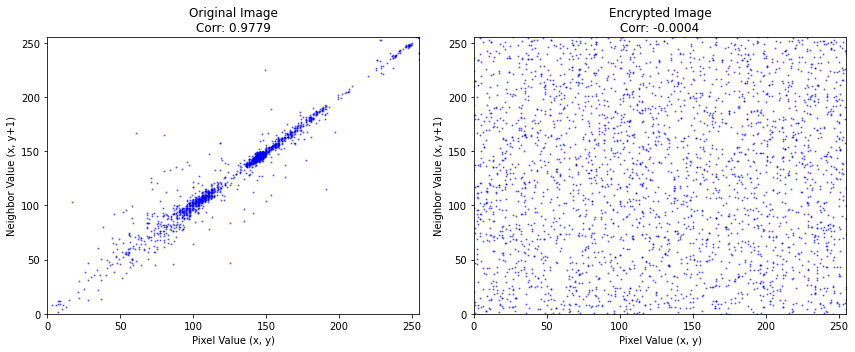

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# CONFIGURATION
# ==========================================
# Number of random pixel pairs to plot (Standard is 2000-3000 for a clean graph)
N_SAMPLES = 3000 

# ==========================================
# CORRELATION FUNCTION
# ==========================================
def analyze_correlation(image, title, ax):
    # Use only one channel (Red) for analysis
    if len(image.shape) == 3:
        data = image[:, :, 0]
    else:
        data = image

    h, w = data.shape
    
    # 1. Horizontal Correlation (x, x+1)
    # We take N_SAMPLES random indices
    x = np.random.randint(0, h, N_SAMPLES)
    y = np.random.randint(0, w-1, N_SAMPLES)
    
    # Get pixel values and their neighbors
    val_x = data[x, y]
    val_y = data[x, y+1]
    
    # Calculate Coefficient (using all pixels for accuracy, not just samples)
    flat_x = data[:, :-1].flatten()
    flat_y = data[:, 1:].flatten()
    corr_val = np.corrcoef(flat_x, flat_y)[0, 1]
    
    # 2. Plot
    ax.scatter(val_x, val_y, s=1, c='blue', alpha=0.5)
    ax.set_title(f"{title}\nCorr: {corr_val:.4f}")
    ax.set_xlabel("Pixel Value (x, y)")
    ax.set_ylabel("Neighbor Value (x, y+1)")
    ax.set_xlim([0, 255])
    ax.set_ylim([0, 255])
    
    return corr_val

# ==========================================
# MAIN EXECUTION
# ==========================================
# Prepare Images
# Ensure 'img_arr' (Original) and 'flat_c1' (Encrypted) exist from previous code
try:
    enc_display = flat_c1.reshape(h, w, c).astype(np.uint8)
except NameError:
    print("Error: Variables 'img_arr' or 'flat_c1' not found. Run the encryption code first.")
    exit()

print("\nRunning Correlation Analysis...")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 1. Original Image Correlation
c_orig = analyze_correlation(img_arr, "Original Image", axes[0])

# 2. Encrypted Image Correlation
c_enc = analyze_correlation(enc_display, "Encrypted Image", axes[1])

plt.tight_layout()
plt.savefig("Correlation_Analysis.png", dpi=300)
print(f"Correlation Plot saved to 'Correlation_Analysis.png'")
print("-" * 30)
print(f"Original Correlation:  {c_orig:.5f}  (Should be near 1.0)")
print(f"Encrypted Correlation: {c_enc:.5f}  (Should be near 0.0)")
print("-" * 30)

plt.show()